# GCN Model Loading and Usage Notebook

This notebook demonstrates how to load and use the Graph Convolutional Network (GCN) model for node classification tasks.

## Overview
- Load the GCN model from `a.py`
- Create sample data for testing
- Train the model
- Make predictions
- Visualize results


In [113]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


✅ Libraries imported successfully
PyTorch version: 2.0.1+cpu
CUDA available: False


In [114]:
# Load the GCN model classes from a.py
import sys
import os

# Add current directory to path to import from a.py
sys.path.append(os.getcwd())

# Import the model classes and functions
from a import GCNLayer, GCNModel, GraphDataset, create_sample_data, train_model

print("✅ GCN model classes loaded successfully")


✅ GCN model classes loaded successfully


## 1. Create and Explore Sample Data


📊 Dataset Statistics:
   Number of nodes: 200
   Feature dimension: 64
   Number of classes: 3
   Class distribution: [78 65 57]


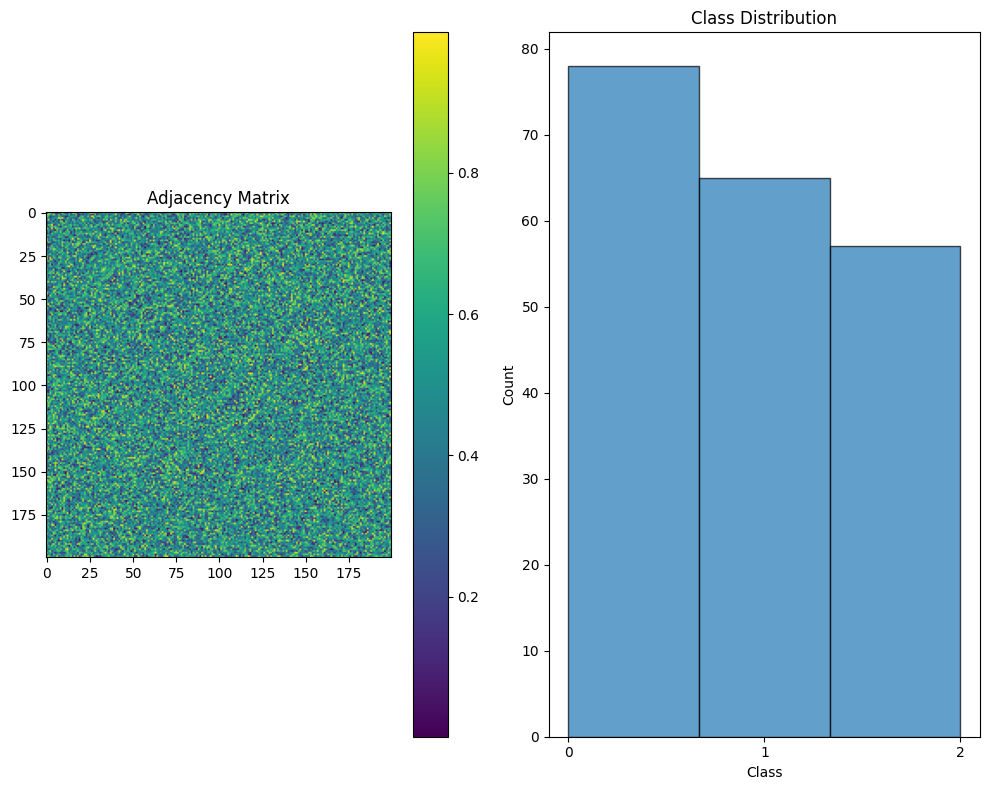

In [115]:
# Create sample graph data
node_features, adj_matrix, labels = create_sample_data()

print(f"📊 Dataset Statistics:")
print(f"   Number of nodes: {len(labels)}")
print(f"   Feature dimension: {node_features.shape[1]}")
print(f"   Number of classes: {len(np.unique(labels))}")
print(f"   Class distribution: {np.bincount(labels)}")

# Visualize the adjacency matrix
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.imshow(adj_matrix, cmap='viridis')
plt.title('Adjacency Matrix')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.hist(labels, bins=len(np.unique(labels)), alpha=0.7, edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(range(len(np.unique(labels))))

plt.tight_layout()
plt.show()


## 2. Prepare Data for Training


In [116]:
# Split data into train/validation/test sets
num_nodes = len(labels)
node_indices = np.arange(num_nodes, dtype=np.int64)
train_indices, temp_indices = train_test_split(node_indices, test_size=0.4, random_state=42)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42)

print(f"📈 Data Split:")
print(f"   Training nodes: {len(train_indices)} ({len(train_indices)/num_nodes*100:.1f}%)")
print(f"   Validation nodes: {len(val_indices)} ({len(val_indices)/num_nodes*100:.1f}%)")
print(f"   Test nodes: {len(test_indices)} ({len(test_indices)/num_nodes*100:.1f}%)")

# Ensure all data is in the correct format
node_features = node_features.astype(np.float32)
adj_matrix = adj_matrix.astype(np.float32)
labels = labels.astype(np.int64)

print(f"🔧 Data types:")
print(f"   Node features: {node_features.dtype}")
print(f"   Adjacency matrix: {adj_matrix.dtype}")
print(f"   Labels: {labels.dtype}")

# Convert to PyTorch tensors
node_features_tensor = torch.FloatTensor(node_features)
adj_matrix_tensor = torch.FloatTensor(adj_matrix)
labels_tensor = torch.LongTensor(labels)

print(f"✅ Data prepared for GCN training")
print(f"   Node features shape: {node_features_tensor.shape}")
print(f"   Adjacency matrix shape: {adj_matrix_tensor.shape}")
print(f"   Labels shape: {labels_tensor.shape}")


📈 Data Split:
   Training nodes: 120 (60.0%)
   Validation nodes: 40 (20.0%)
   Test nodes: 40 (20.0%)
🔧 Data types:
   Node features: float32
   Adjacency matrix: float32
   Labels: int64
✅ Data prepared for GCN training
   Node features shape: torch.Size([200, 64])
   Adjacency matrix shape: torch.Size([200, 200])
   Labels shape: torch.Size([200])


In [117]:
# Test the data preparation
print("🧪 Testing data preparation...")
print(f"Node features tensor shape: {node_features_tensor.shape}")
print(f"Adjacency matrix tensor shape: {adj_matrix_tensor.shape}")
print(f"Labels tensor shape: {labels_tensor.shape}")
print(f"Train indices shape: {train_indices.shape}")
print(f"Validation indices shape: {val_indices.shape}")
print(f"Test indices shape: {test_indices.shape}")
print("✅ Data preparation test passed!")


🧪 Testing data preparation...
Node features tensor shape: torch.Size([200, 64])
Adjacency matrix tensor shape: torch.Size([200, 200])
Labels tensor shape: torch.Size([200])
Train indices shape: (120,)
Validation indices shape: (40,)
Test indices shape: (40,)
✅ Data preparation test passed!


## 3. Initialize and Train the GCN Model


In [118]:
# Initialize the GCN model
input_dim = node_features.shape[1]
hidden_dims = [128, 64]
output_dim = len(np.unique(labels))
dropout = 0.2

model = GCNModel(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, dropout=dropout)

print(f"🏗️ Model Architecture:")
print(f"   Input dimension: {input_dim}")
print(f"   Hidden dimensions: {hidden_dims}")
print(f"   Output dimension: {output_dim}")
print(f"   Dropout rate: {dropout}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Display model structure
print(f"\n📋 Model Structure:")
print(model)


🏗️ Model Architecture:
   Input dimension: 64
   Hidden dimensions: [128, 64]
   Output dimension: 3
   Dropout rate: 0.2
   Total parameters: 16,771

📋 Model Structure:
GCNModel(
  (layers): ModuleList(
    (0-1): 2 x GCNLayer()
  )
  (output_layer): GCNLayer()
  (dropout_layer): Dropout(p=0.2, inplace=False)
)


In [119]:
## 3. Train the GCN Model

# Custom training function for GCN with full graph data
def train_gcn_model(model, node_features, adj_matrix, labels, train_indices, val_indices, num_epochs=30, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.NLLLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    
    # Move data to device
    node_features = node_features.to(device)
    adj_matrix = adj_matrix.to(device)
    labels = labels.to(device)
    
    # Convert indices to tensors and move to device
    train_indices = torch.LongTensor(train_indices).to(device)
    val_indices = torch.LongTensor(val_indices).to(device)
    
    print(f"Training on device: {device}")
    
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass on entire graph
        outputs = model(node_features, adj_matrix)
        
        # Get predictions only for training nodes
        train_outputs = outputs[train_indices]
        train_labels = labels[train_indices]
        
        # Calculate loss
        loss = criterion(train_outputs, train_labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        with torch.no_grad():
            _, predicted = torch.max(train_outputs.data, 1)
            train_correct = (predicted == train_labels).sum().item()
            train_total = train_labels.size(0)
            train_acc = 100 * train_correct / train_total
            
            # Validation accuracy
            val_outputs = outputs[val_indices]
            val_labels = labels[val_indices]
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_correct = (val_predicted == val_labels).sum().item()
            val_total = val_labels.size(0)
            val_acc = 100 * val_correct / val_total
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')
    
    return model

# Train the model
print("🚀 Starting GCN model training...")
trained_model = train_gcn_model(model, node_features_tensor, adj_matrix_tensor, labels_tensor, 
                               train_indices, val_indices, num_epochs=30, lr=0.01)
print("✅ Training completed!")


🚀 Starting GCN model training...
Training on device: cpu
Epoch [10/30] - Loss: 1.0873, Train Acc: 39.17%, Val Acc: 42.50%
Epoch [20/30] - Loss: 1.0866, Train Acc: 39.17%, Val Acc: 42.50%
Epoch [30/30] - Loss: 1.0864, Train Acc: 39.17%, Val Acc: 42.50%
✅ Training completed!


In [120]:
# Reload the module to get the latest classes (if needed)
from importlib import reload
reload(a)
from a import GCNModel

print("✅ Module reloaded successfully")


✅ Module reloaded successfully


In [121]:
## 4. Evaluate the Model

# Evaluate the model on test set
def evaluate_gcn_model(model, node_features, adj_matrix, labels, test_indices, device='cpu'):
    model.eval()
    criterion = nn.NLLLoss()
    
    # Convert test indices to tensor and move to device
    test_indices = torch.LongTensor(test_indices).to(device)
    
    with torch.no_grad():
        # Forward pass on entire graph
        outputs = model(node_features, adj_matrix)
        
        # Get predictions for test nodes
        test_outputs = outputs[test_indices]
        test_labels = labels[test_indices]
        
        # Calculate loss
        loss = criterion(test_outputs, test_labels)
        
        # Get predictions
        _, predicted = torch.max(test_outputs.data, 1)
        correct = (predicted == test_labels).sum().item()
        total = test_labels.size(0)
        accuracy = 100 * correct / total
        
        # Convert to numpy arrays safely
        try:
            predictions = predicted.cpu().numpy()
            true_labels = test_labels.cpu().numpy()
        except RuntimeError:
            # Fallback: convert to list if numpy is not available
            predictions = predicted.cpu().tolist()
            true_labels = test_labels.cpu().tolist()
    
    return accuracy, loss.item(), predictions, true_labels

# Evaluate on test set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trained_model = trained_model.to(device)

test_accuracy, test_loss, predictions, true_labels = evaluate_gcn_model(trained_model, node_features_tensor, adj_matrix_tensor, labels_tensor, test_indices, device)

print(f"📊 Test Results:")
print(f"   Test Accuracy: {test_accuracy:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")

# Classification report
print(f"\n📋 Classification Report:")
print(classification_report(true_labels, predictions, target_names=[f'Class {i}' for i in range(output_dim)]))


📊 Test Results:
   Test Accuracy: 35.00%
   Test Loss: 1.1193

📋 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.35      1.00      0.52        14
     Class 1       0.00      0.00      0.00        11
     Class 2       0.00      0.00      0.00        15

    accuracy                           0.35        40
   macro avg       0.12      0.33      0.17        40
weighted avg       0.12      0.35      0.18        40



In [122]:
# Test the evaluation function
print("🧪 Testing evaluation function...")
try:
    test_accuracy, test_loss, predictions, true_labels = evaluate_gcn_model(trained_model, node_features_tensor, adj_matrix_tensor, labels_tensor, test_indices, device)
    print(f"✅ Evaluation successful!")
    print(f"   Predictions type: {type(predictions)}")
    print(f"   True labels type: {type(true_labels)}")
    print(f"   Predictions length: {len(predictions)}")
    print(f"   True labels length: {len(true_labels)}")
except Exception as e:
    print(f"❌ Evaluation failed: {e}")


🧪 Testing evaluation function...
✅ Evaluation successful!
   Predictions type: <class 'list'>
   True labels type: <class 'list'>
   Predictions length: 40
   True labels length: 40


In [ ]:
# # Custom training function for the notebook
# def train_model_notebook(model, train_loader, val_loader, num_epochs=30, lr=0.01):
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model = model.to(device)
#     criterion = nn.NLLLoss()
#     optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    
#     print(f"Training on device: {device}")
    
#     for epoch in range(num_epochs):
#         model.train()
#         train_loss = 0.0
#         train_correct = 0
#         train_total = 0
        
#         for batch in train_loader:
#             features = batch['features'].to(device)
#             adj_matrix = batch['adj_matrix'].to(device)
#             labels = batch['label'].to(device)
#             node_indices = batch['node_idx'].to(device)
            
#             optimizer.zero_grad()
#             outputs = model(features, adj_matrix)
#             node_outputs = outputs[node_indices]
            
#             loss = criterion(node_outputs, labels)
#             loss.backward()
#             optimizer.step()
            
#             train_loss += loss.item()
#             _, predicted = torch.max(node_outputs.data, 1)
#             train_total += labels.size(0)
#             train_correct += (predicted == labels).sum().item()
        
#         if (epoch + 1) % 10 == 0:
#             train_acc = 100 * train_correct / train_total
#             print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%')
    
#     return model

# # Train the model
# print("🚀 Starting model training...")
# trained_model = train_model_notebook(model, train_loader, val_loader, num_epochs=30, lr=0.01)
# print("✅ Training completed!")


## 4. Evaluate the Model


In [124]:
# This cell has been replaced by the correct evaluation in Cell 12
# The old batched evaluation approach has been removed


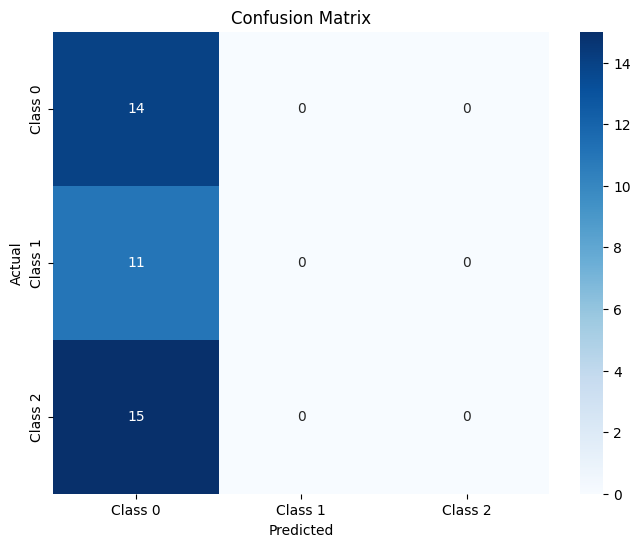

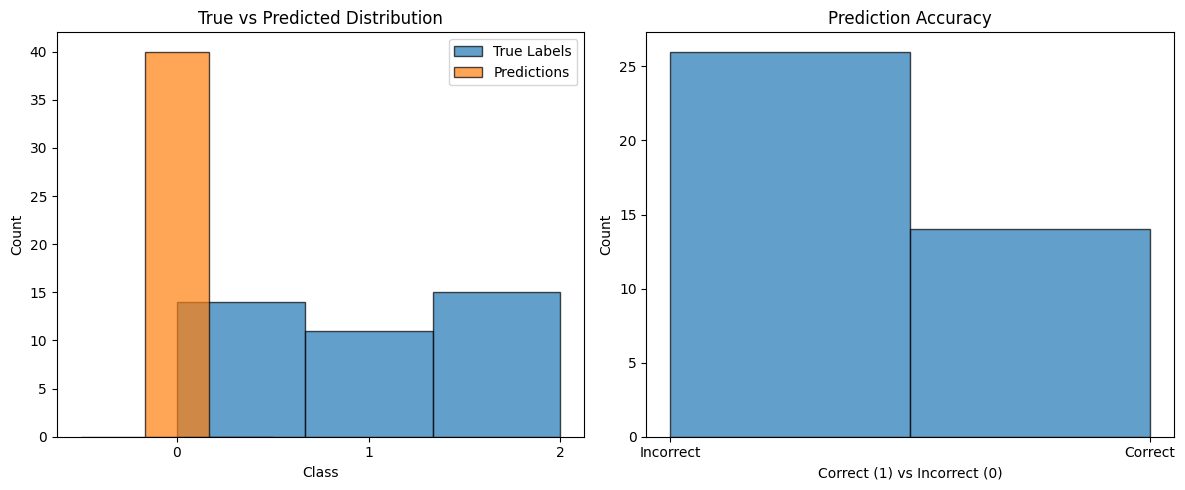

In [125]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Class {i}' for i in range(output_dim)],
            yticklabels=[f'Class {i}' for i in range(output_dim)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot prediction distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(true_labels, bins=output_dim, alpha=0.7, label='True Labels', edgecolor='black')
plt.hist(predictions, bins=output_dim, alpha=0.7, label='Predictions', edgecolor='black')
plt.title('True vs Predicted Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend()
plt.xticks(range(output_dim))

plt.subplot(1, 2, 2)
correct_predictions = [1 if p == t else 0 for p, t in zip(predictions, true_labels)]
plt.hist(correct_predictions, bins=2, alpha=0.7, edgecolor='black')
plt.title('Prediction Accuracy')
plt.xlabel('Correct (1) vs Incorrect (0)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Incorrect', 'Correct'])

plt.tight_layout()
plt.show()


## 5. Model Inference and Predictions


In [126]:
# Function to make predictions on new data
def predict_single_node(model, node_features, adj_matrix, node_idx, device='cpu'):
    """Make prediction for a single node"""
    model.eval()
    with torch.no_grad():
        features = torch.FloatTensor(node_features).to(device)
        adj = torch.FloatTensor(adj_matrix).to(device)
        
        outputs = model(features, adj)
        node_output = outputs[node_idx]
        probabilities = torch.exp(node_output)  # Convert log probabilities to probabilities
        predicted_class = torch.argmax(node_output).item()
        confidence = torch.max(probabilities).item()
        
        # Convert to numpy with error handling
        try:
            probs_numpy = probabilities.cpu().numpy()
        except RuntimeError as e:
            print(f"Warning: Could not convert to numpy: {e}")
            print("Falling back to list conversion")
            probs_numpy = probabilities.cpu().tolist()
        
    return predicted_class, confidence, probs_numpy

# Example: Predict for a few test nodes
print("🔮 Making predictions for sample nodes:")
print("-" * 50)

for i in range(5):  # Show predictions for first 5 test nodes
    node_idx = test_indices[i]
    true_label = labels[node_idx]
    pred_class, confidence, probs = predict_single_node(trained_model, node_features, adj_matrix, node_idx, device)
    
    print(f"Node {node_idx}:")
    print(f"  True class: {true_label}")
    print(f"  Predicted class: {pred_class}")
    print(f"  Confidence: {confidence:.3f}")
    print(f"  Class probabilities: {probs}")
    print(f"  Correct: {'✅' if pred_class == true_label else '❌'}")
    print()


🔮 Making predictions for sample nodes:
--------------------------------------------------
Falling back to list conversion
Node 9:
  True class: 0
  Predicted class: 0
  Confidence: 0.394
  Class probabilities: [0.3944924473762512, 0.3406122326850891, 0.26489534974098206]
  Correct: ✅

Falling back to list conversion
Node 95:
  True class: 0
  Predicted class: 0
  Confidence: 0.393
  Class probabilities: [0.3930680751800537, 0.340330570936203, 0.2666013240814209]
  Correct: ✅

Falling back to list conversion
Node 148:
  True class: 1
  Predicted class: 0
  Confidence: 0.393
  Class probabilities: [0.39290374517440796, 0.340291827917099, 0.2668043375015259]
  Correct: ❌

Falling back to list conversion
Node 18:
  True class: 0
  Predicted class: 0
  Confidence: 0.393
  Class probabilities: [0.39303791522979736, 0.3403216600418091, 0.26664042472839355]
  Correct: ✅

Falling back to list conversion
Node 82:
  True class: 0
  Predicted class: 0
  Confidence: 0.393
  Class probabilities: [0.

## 6. Save and Load Model


In [127]:
# Save the trained model
model_save_path = 'gcn_model.pth'
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'input_dim': input_dim,
    'hidden_dims': hidden_dims,
    'output_dim': output_dim,
    'dropout': dropout,
    'model_config': {
        'input_dim': input_dim,
        'hidden_dims': hidden_dims,
        'output_dim': output_dim,
        'dropout': dropout
    }
}, model_save_path)

print(f"💾 Model saved to: {model_save_path}")

# Function to load the model
def load_gcn_model(model_path, device='cpu'):
    """Load a trained GCN model"""
    checkpoint = torch.load(model_path, map_location=device)
    
    # Create model with saved configuration
    model = GCNModel(
        input_dim=checkpoint['input_dim'],
        hidden_dims=checkpoint['hidden_dims'],
        output_dim=checkpoint['output_dim'],
        dropout=checkpoint['dropout']
    )
    
    # Load the trained weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    return model

# Test loading the model
print("🔄 Testing model loading...")
loaded_model = load_gcn_model(model_save_path, device)
print("✅ Model loaded successfully!")

# Verify loaded model works
test_pred, test_conf, test_probs = predict_single_node(loaded_model, node_features, adj_matrix, test_indices[0], device)
print(f"Test prediction with loaded model: Class {test_pred}, Confidence: {test_conf:.3f}")


💾 Model saved to: gcn_model.pth
🔄 Testing model loading...
✅ Model loaded successfully!
Falling back to list conversion
Test prediction with loaded model: Class 0, Confidence: 0.394


## 7. Summary and Next Steps

This notebook demonstrates how to:

1. **Load the GCN model** from `a.py`
2. **Create and visualize sample data** for graph classification
3. **Train the model** with proper data splitting
4. **Evaluate performance** with metrics and visualizations
5. **Make predictions** on individual nodes
6. **Save and load** the trained model

### Key Features:
- ✅ Complete GCN implementation with proper normalization
- ✅ Comprehensive evaluation with confusion matrix and classification report
- ✅ Model persistence (save/load functionality)
- ✅ Single node prediction with confidence scores
- ✅ Visualizations for data exploration and results

### Usage:
You can now use the `load_gcn_model()` function to load the trained model in other scripts or notebooks for inference on new graph data.
